In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import  mean_absolute_error, r2_score, root_mean_squared_error

# Exploration du dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

print("Description du dataset :\n", diabetes.DESCR[:500], "...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


# Normalisation des données
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# KNN sans optimisation du choix de k
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)


Description du dataset :
 .. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measur ...


KNeighborsRegressor()

In [33]:
# Evaluation du modèle
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)


train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_RMSE = root_mean_squared_error(y_test, y_pred_test)
test_RMSE = root_mean_squared_error(y_test, y_pred_test)
train_MAE = mean_absolute_error(y_train, y_pred_train)
test_MAE = mean_absolute_error(y_test, y_pred_test)

performance_table = pd.DataFrame({
    'Métriques': ['R² Score', 'RMSE', 'MAE'],
    'Entraînement': [train_r2, train_RMSE, train_MAE],
    'Test': [test_r2, test_RMSE, test_MAE]
})

print("Performance du modèle KNN sans optimisation :")
print(performance_table)

Performance du modèle KNN sans optimisation :
  Métriques  Entraînement       Test
0  R² Score      0.568451   0.431260
1      RMSE     56.079924  56.079924
2       MAE     40.838671  43.016216


In [34]:
# Recherche du meilleur k 
param_grid = {
    'n_neighbors': np.arange(1, 31, 1),          # 1,3,5,...,29
    'weights': ['uniform', 'distance']
}

knn = KNeighborsRegressor()
grid_search = GridSearchCV(
    knn, param_grid, cv=7, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\n--- Meilleurs paramètres ---")
print("Meilleur k et weights :", grid_search.best_params_)
print("Meilleur R² (CV)      :", grid_search.best_score_.round(3))

Fitting 7 folds for each of 60 candidates, totalling 420 fits

--- Meilleurs paramètres ---
Meilleur k et weights : {'n_neighbors': np.int64(16), 'weights': 'distance'}
Meilleur R² (CV)      : 0.398


In [35]:
# Modèle optimisé
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

# Ensemble de validation pour l'optimisation des hyperparamètres
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)


In [36]:
# Evaluation du modèle
y_pred_train = best_knn.predict(X_train)
y_pred_test = best_knn.predict(X_test)


train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_RMSE = root_mean_squared_error(y_train, y_pred_train)
test_RMSE = root_mean_squared_error(y_test, y_pred_test)
train_MAE = mean_absolute_error(y_train, y_pred_train)
test_MAE = mean_absolute_error(y_test, y_pred_test)

performance_table = pd.DataFrame({
    'Métriques': ['R² Score', 'RMSE', 'MAE'],
    'Entraînement': [train_r2, train_RMSE, train_MAE],
    'Test': [test_r2, test_RMSE, test_MAE]
})
print("\n Performance du modèle optimisé :")
print(performance_table)


 Performance du modèle optimisé :
  Métriques  Entraînement       Test
0  R² Score           1.0   0.470426
1      RMSE           0.0  54.114516
2       MAE           0.0  43.540634


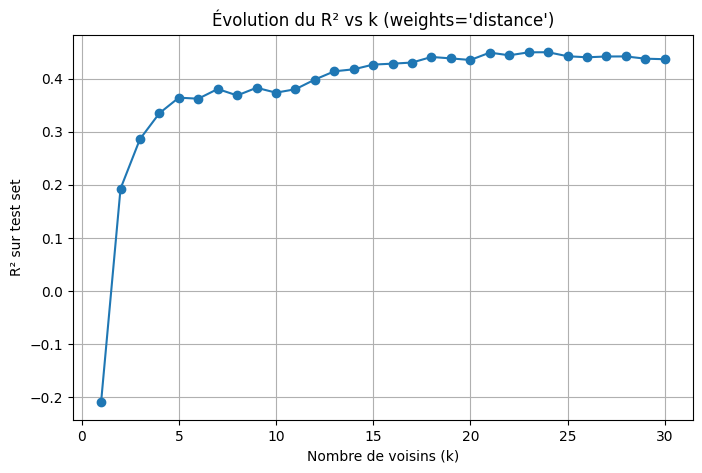

In [37]:


# visualiser l'évolution du R² vs k
r2_scores = []
for k in range(1, 31):
    knn_k = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn_k.fit(X_train, y_train)
    r2_scores.append(r2_score(y_test, knn_k.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(range(1,31), r2_scores, marker='o')
plt.xlabel("Nombre de voisins (k)")
plt.ylabel("R² sur test set")
plt.title("Évolution du R² vs k (weights='distance')")
plt.grid(True)
plt.show()